In [2]:
import os 
import yaml
import matplotlib.pyplot as plt 
import numpy as np 

from utils.general_utils import load_config
from utils.dataset import load_dataset
from utils.camera_utils import Camera
from utils.pose_utils import getProjectionMatrix2

### load dataset 

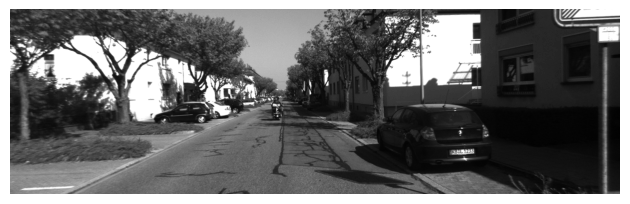

pose: 
 tensor([[ 1.0000e+00, -9.0437e-12, -2.3268e-11, -5.5511e-17],
        [-9.0437e-12,  1.0000e+00, -2.3924e-10, -3.3307e-16],
        [-2.3268e-11, -2.3924e-10,  1.0000e+00,  4.4409e-16],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  1.0000e+00]],
       dtype=torch.float64)
intrinsics: 
 [[718.856    0.     607.1928]
 [  0.     718.856  185.2157]
 [  0.       0.       1.    ]]


In [3]:
path_config = "configs/kitti_sequences/kitti_00.yaml"
config = load_config(path_config)
dataset = load_dataset(args=None, path=None, config=config)

image, _, pose = dataset[0]
plt.imshow(image.permute(1, 2, 0), cmap='gray')
plt.axis("off"); plt.tight_layout()
plt.show()

print("pose: \n", pose)
print("intrinsics: \n", dataset.K)

### test camera 

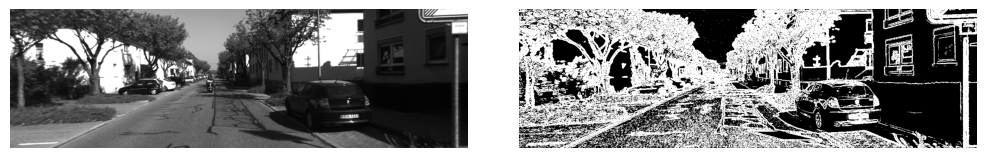

In [4]:
device = "cpu"
projection_matrix = getProjectionMatrix2(
    znear=0.01,
    zfar=100.0,
    fx=dataset.fx,
    fy=dataset.fy,
    cx=dataset.cx,
    cy=dataset.cy,
    W=dataset.width,
    H=dataset.height,
).transpose(0, 1)
projection_matrix = projection_matrix.to(device=device)
viewpoint = Camera.init_from_dataset(dataset=dataset, idx=0, projection_matrix=projection_matrix)
grad_mask = viewpoint.compute_grad_mask(config=config)

fig = plt.figure(figsize=(10, 5))
plt.subplot(121); plt.imshow(viewpoint.original_image.permute(1, 2, 0), cmap="gray"); plt.tight_layout(); plt.axis("off")
plt.subplot(122); plt.imshow(viewpoint.grad_mask.permute(1, 2, 0), cmap="gray"); plt.tight_layout(); plt.axis("off")
plt.show()

In [5]:
viewpoint.R_gt, viewpoint.T_gt

(tensor([[1.0000e+00, 9.0437e-12, 2.3268e-11],
         [9.0437e-12, 1.0000e+00, 2.3924e-10],
         [2.3268e-11, 2.3924e-10, 1.0000e+00]], dtype=torch.float64),
 tensor([ 5.5511e-17,  3.3307e-16, -4.4409e-16], dtype=torch.float64))

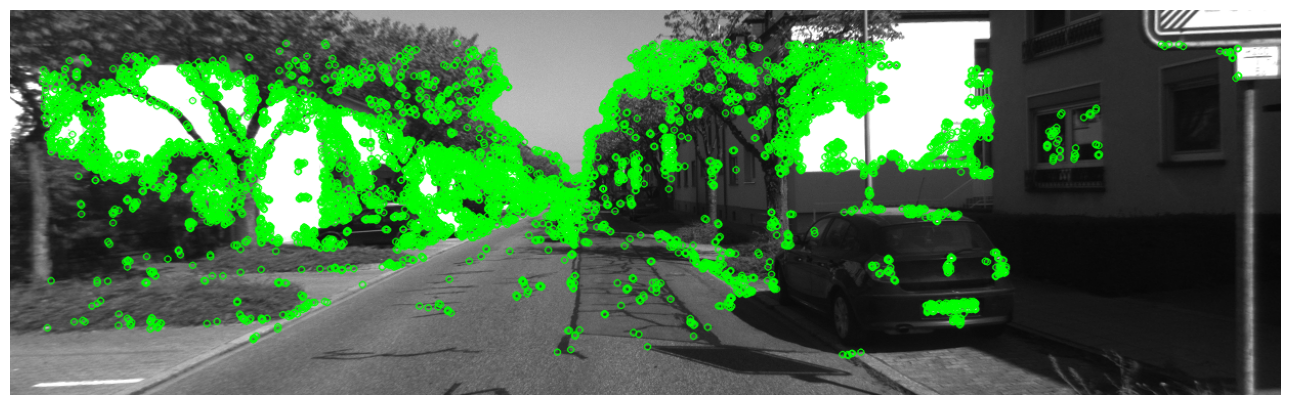

In [5]:
import cv2 

img = (viewpoint.original_image.squeeze().numpy() * 255).astype(np.uint8)

# Create ORB object
max_num_features = 10000
orb = cv2.ORB_create(max_num_features)
keypoints, descriptors = orb.detectAndCompute(img, None)

# Draw features
img2 = cv2.drawKeypoints(img, keypoints, None, color=(0, 255, 0), flags=0)
plt.figure(figsize=(20, 5))
plt.imshow(img2)
plt.axis("off")
plt.show()

In [49]:
import json 

path_traj = "results_00/kitti_00/2025-03-15-17-04-38/plot/trj_final.json"
with open(path_traj) as file:
    data = json.load(file)

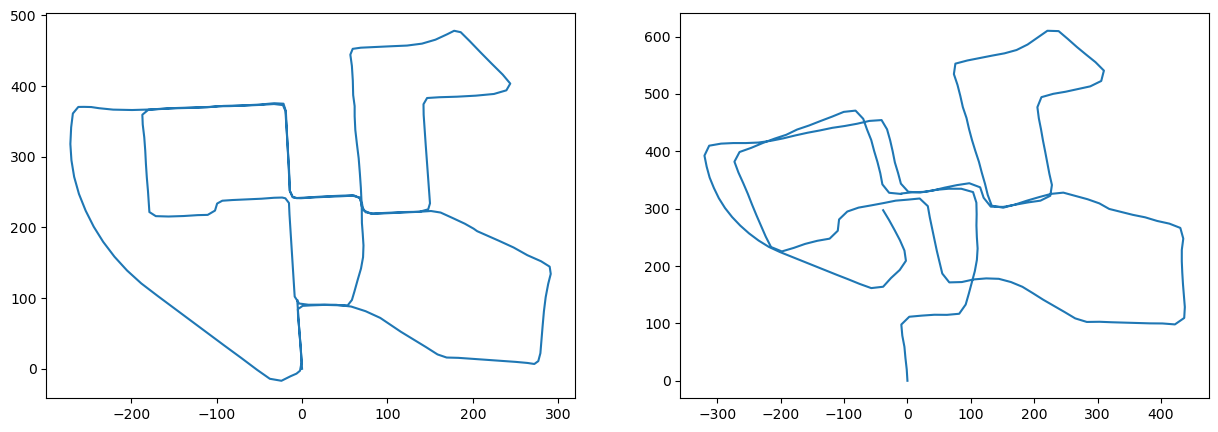

In [51]:
traj_gt = np.array(data["trj_gt"])
traj_est = np.array(data["trj_est"])

traj_gt_corrected = [np.linalg.inv(traj_gt[i]) for i in range(len(traj_gt))]
trans_gt = np.array([traj_gt_corrected[i][:3, 3] for i in range(len(traj_gt_corrected))])
trans_est = np.array([traj_est[i][:3, 3] for i in range(len(traj_est))])

fig = plt.figure(figsize=(15, 5))
plt.subplot(121); plt.plot(trans_gt[:, 0], trans_gt[:, 2])
plt.subplot(122); plt.plot(trans_est[:, 0], trans_est[:, 2])
plt.show()